# Further tests of functions that produce the boundary of stable islands

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.analysis.stable_islands import outer_irc_point_stable_island
from src.integrator.integrate import FastSitnikovSimulation
from src.utils.plotting import polar_scatter
from src.utils.curve_ordering import fit_closed_curve_from_cloud


## Island 2

In [ ]:
E = 0.5
p0_second_island = (1.321, np.pi)

ans = outer_irc_point_stable_island(e = E, p0 = p0_second_island)

In [7]:
print(ans)

{'point': (1.3419189999999999, 3.141592653589793), 'distance_estimate': 0.0001372500000000887, 'status': 'converged', 'bracket': (1.3419189999999999, 1.34205625)}


In [3]:
def plot_orbit(p_start, E, N_it):
    iterates_t = np.zeros(N_it)
    iterates_v = np.zeros(N_it)

    sim = FastSitnikovSimulation(e=E)
    p_curr = p_start

    for i in range(N_it):
        p_curr = sim.phi_fast(p_curr[0], p_curr[1])
        iterates_t[i] = p_curr[1]
        iterates_v[i] = p_curr[0]

    plt.scatter(iterates_t, iterates_v, s=10)
    plt.show()

p_outer = ans['point']

eps: 0.000, p_start: (1.3419189999999999, 3.141592653589793)


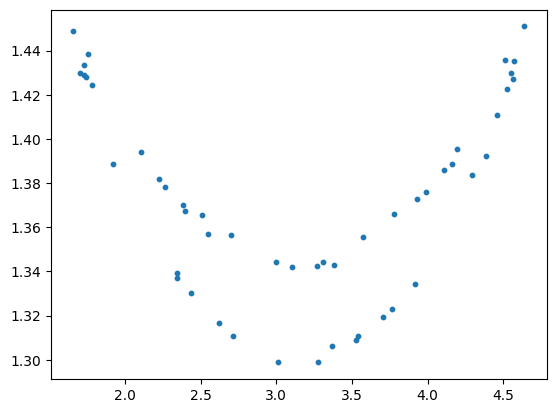

eps: 0.010, p_start: (1.3417098099999998, 3.141592653589793)


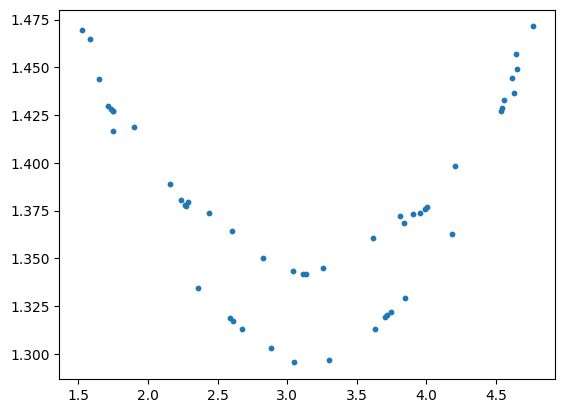

eps: 0.010, p_start: (1.3417098099999998, 3.141592653589793)


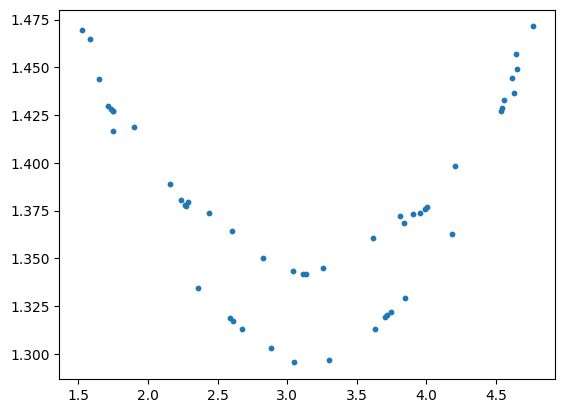

eps: 0.050, p_start: (1.3408730499999997, 3.141592653589793)


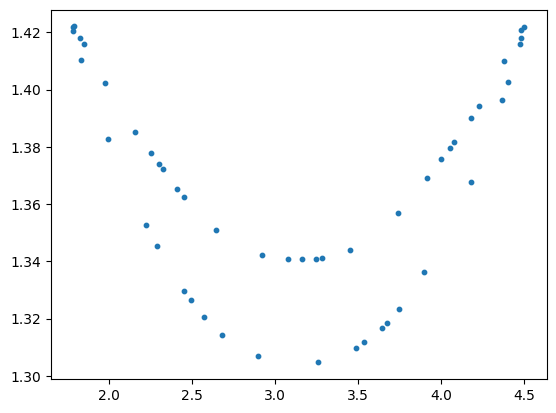

eps: 0.100, p_start: (1.3398271, 3.141592653589793)


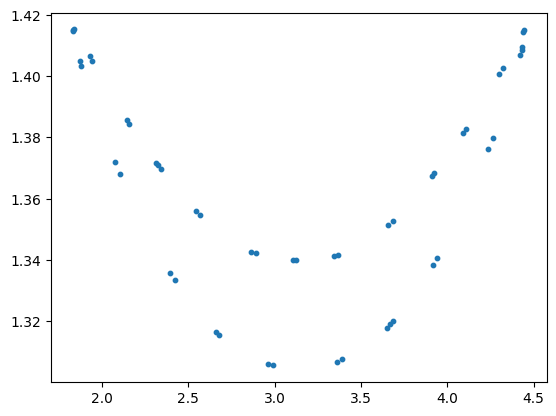

eps: 0.200, p_start: (1.3377352, 3.141592653589793)


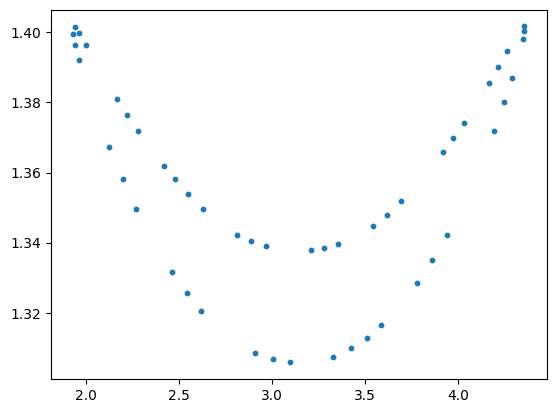

eps: 0.300, p_start: (1.3356432999999999, 3.141592653589793)


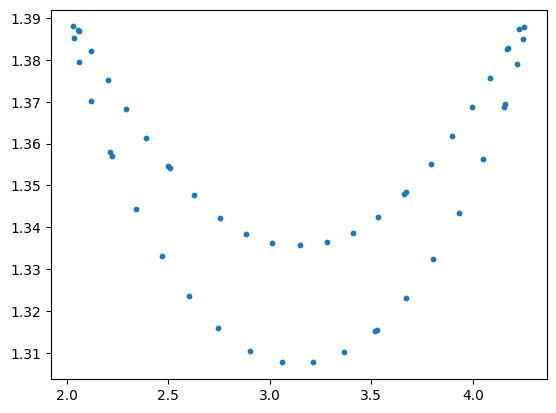

eps: 0.400, p_start: (1.3335513999999997, 3.141592653589793)


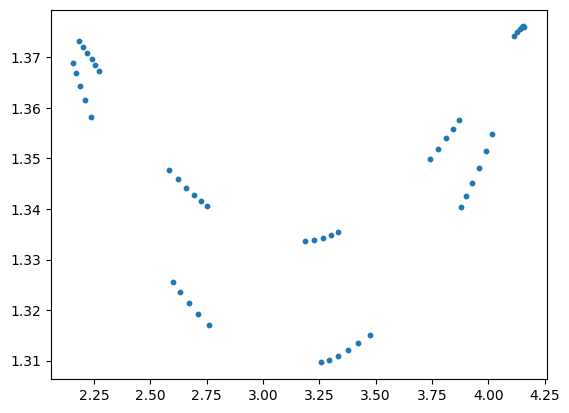

eps: 0.500, p_start: (1.3314594999999998, 3.141592653589793)


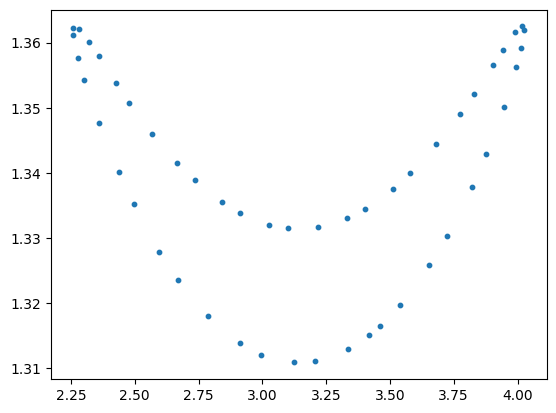

eps: 0.600, p_start: (1.3293675999999999, 3.141592653589793)


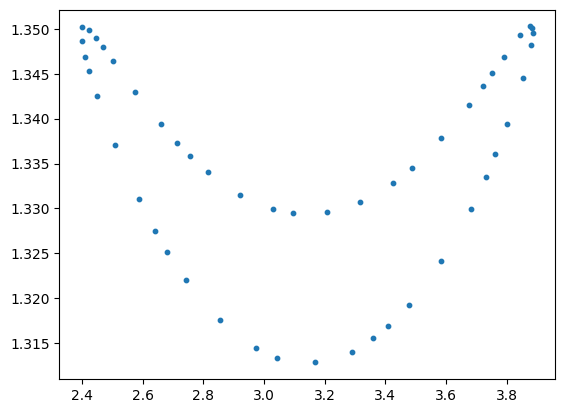

eps: 0.700, p_start: (1.3272757, 3.141592653589793)


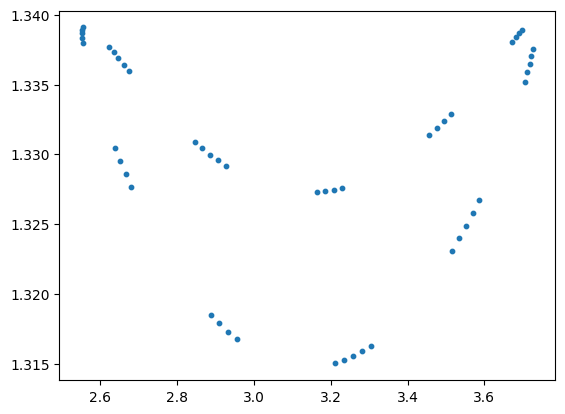

eps: 0.800, p_start: (1.3251837999999998, 3.141592653589793)


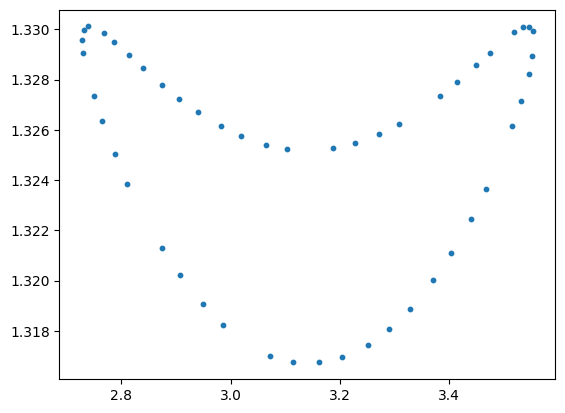

eps: 0.900, p_start: (1.3230919, 3.141592653589793)


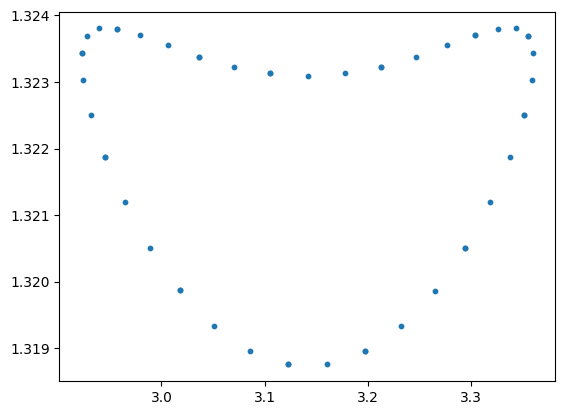

eps: 1.000, p_start: (1.321, 3.141592653589793)


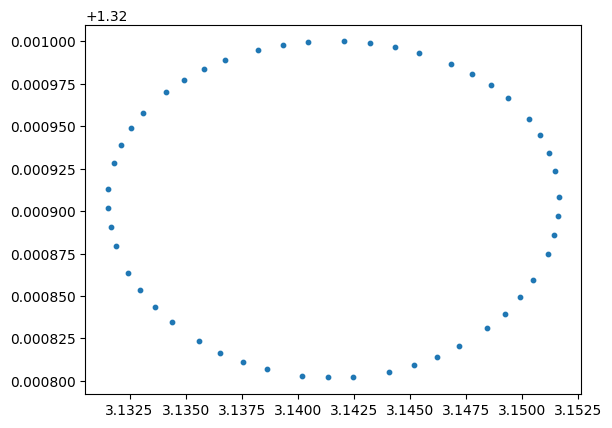

In [9]:
for eps in [0.0, 0.01, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    p_start = ((1-eps)*p_outer[0] + eps*p0_second_island[0], (1-eps)*p_outer[1] + eps*p0_second_island[1])
    print(f"eps: {eps:.3f}, p_start: {p_start}")
    plot_orbit(p_start, E, 50)
    

From experience it seems like eps = 0.1 is a good value to ensure a quasi-periodic behaviour

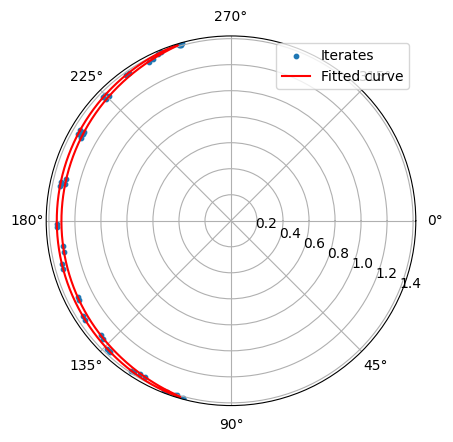

Angular span (unwrapped): 0.225939
Detected seam splits: 0


In [ ]:
eps = 0.1
p_start = ((1-eps)*p_outer[0] + eps*p0_second_island[0], (1-eps)*p_outer[1] + eps*p0_second_island[1])

N_it = 50
iterates_t = np.zeros(N_it)
iterates_v = np.zeros(N_it)
sim = FastSitnikovSimulation(e=E)
p_curr = p_start

for i in range(N_it):
    p_curr = sim.phi_fast(p_curr[0], p_curr[1])
    iterates_t[i] = p_curr[1]
    iterates_v[i] = p_curr[0]

spline = fit_closed_curve_from_cloud(iterates_t, iterates_v)

N_plot = 400
u_vals = np.linspace(0.0, 1.0, N_plot)
points_plot_polar = spline(u_vals)
r_plot = points_plot_polar[0, :]
theta_plot = points_plot_polar[1, :]

split_idx = np.where(np.abs(np.diff(theta_plot)) > np.pi)[0] + 1
segments_theta = np.split(theta_plot, split_idx)
segments_r = np.split(r_plot, split_idx)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.set_theta_direction(-1)
ax.scatter(iterates_t, iterates_v, s=10, label='Iterates')

for k, (th_seg, r_seg) in enumerate(zip(segments_theta, segments_r)):
    lbl = 'Fitted curve' if k == 0 else None
    ax.plot(th_seg, r_seg, color='red', label=lbl)

ax.legend()
plt.show()

## Island 1

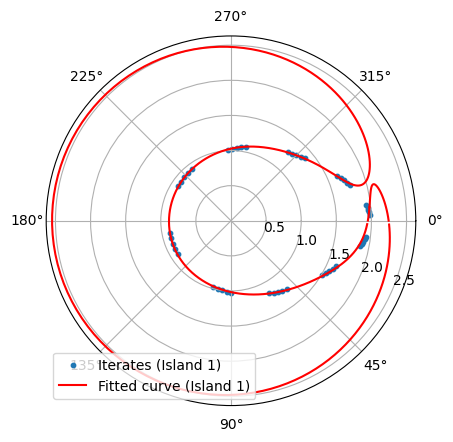

Angular span (unwrapped, island 1): 6.104807
Detected seam splits (island 1): 2


In [ ]:
E = 0.5
p0_first_island = (0.25, 0.10)

ans_first = outer_irc_point_stable_island(e=E, p0=p0_first_island)
p_outer_first = ans_first['point']

eps = 0.15
p_start_first = (
    (1 - eps) * p_outer_first[0] + eps * p0_first_island[0],
    (1 - eps) * p_outer_first[1] + eps * p0_first_island[1],
)

N_it = 50
iterates_t_first = np.zeros(N_it)
iterates_v_first = np.zeros(N_it)
sim_first = FastSitnikovSimulation(e=E)
p_curr = p_start_first

for i in range(N_it):
    p_curr = sim_first.phi_fast(p_curr[0], p_curr[1])
    iterates_t_first[i] = p_curr[1]
    iterates_v_first[i] = p_curr[0]



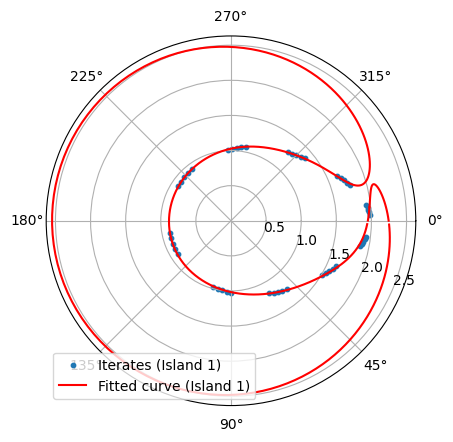

Angular span (unwrapped, island 1): 6.104807
Detected seam splits (island 1): 2


In [ ]:
spline_first = fit_closed_curve_from_cloud(iterates_t_first, iterates_v_first)

N_plot = 400
u_vals_first = np.linspace(0.0, 1.0, N_plot)
points_plot_first_polar = spline_first(u_vals_first)
r_plot_first = points_plot_first_polar[0, :]
theta_plot_first = points_plot_first_polar[1, :]

split_idx_first = np.where(np.abs(np.diff(theta_plot_first)) > np.pi)[0] + 1
segments_theta_first = np.split(theta_plot_first, split_idx_first)
segments_r_first = np.split(r_plot_first, split_idx_first)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.set_theta_direction(-1)
ax.scatter(iterates_t_first, iterates_v_first, s=10, label='Iterates (Island 1)')

for k, (th_seg, r_seg) in enumerate(zip(segments_theta_first, segments_r_first)):
    lbl = 'Fitted curve (Island 1)' if k == 0 else None
    ax.plot(th_seg, r_seg, color='red', label=lbl)

ax.legend()
plt.show()